In [7]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt

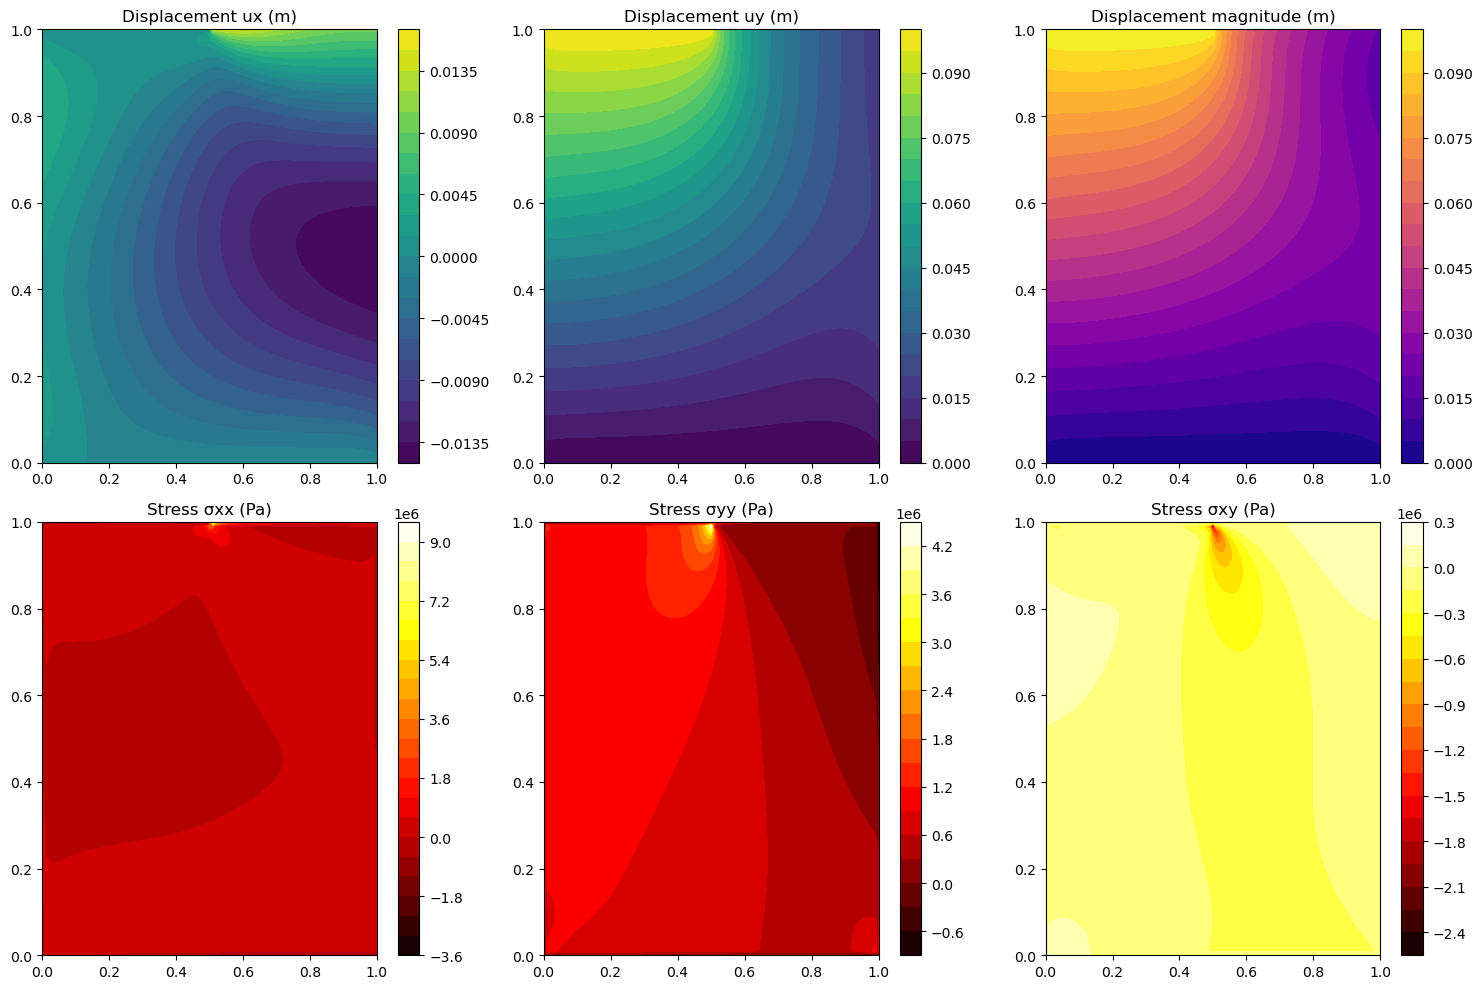

Solution computed successfully.
Grid size: 101x101
Maximum ux: 0.015355 m
Maximum uy: 0.100000 m
Maximum displacement magnitude: 0.100000 m
Maximum σxx: 9261301.69 Pa
Maximum σyy: 4477755.83 Pa
Maximum σxy: 2439794.01 Pa


In [8]:
# Parameters
E = 10e6  # Pa
nu = 0.2
Lx, Ly = 1.0, 1.0  # Domain size
N = 101  # Number of grid points in each direction
h = Lx / (N - 1)  # Grid spacing

# Material constants for plane stress
A = E / (1 - nu**2)  # For normal stresses
B = E / (2 * (1 + nu))  # For shear stress

# Create grid
x = np.linspace(0, Lx, N)
y = np.linspace(0, Ly, N)
X, Y = np.meshgrid(x, y, indexing='ij')

# Initialize displacement arrays
ux = np.zeros((N, N))
uy = np.zeros((N, N))

# Set Dirichlet boundary conditions
mask_prescribed = (X[:, -1] <= 0.5)  # x <= 0.5 at y=1
ux[mask_prescribed, -1] = 0.0
uy[mask_prescribed, -1] = 0.1

# Map grid points to global indices
total_points = N * N
def idx(i, j, var):
    return (i * N + j) * 2 + var  # var: 0 for ux, 1 for uy

# Assemble linear system A*U = b
A_data, A_row, A_col = [], [], []
b = np.zeros(2 * total_points)

# Interior equilibrium equations
for i in range(1, N-1):
    for j in range(1, N-1):
        if j == N-1 and mask_prescribed[i]:
            continue  # Skip prescribed points
        
        # Equation for ux at (i,j)
        row_ux = idx(i, j, 0)
        # d2ux/dx2
        A_data.extend([A/h**2, -2*A/h**2, A/h**2])
        A_row.extend([row_ux]*3)
        A_col.extend([idx(i+1, j, 0), idx(i, j, 0), idx(i-1, j, 0)])
        # d2ux/dy2
        A_data.extend([B/h**2, -2*B/h**2, B/h**2])
        A_row.extend([row_ux]*3)
        A_col.extend([idx(i, j+1, 0), idx(i, j, 0), idx(i, j-1, 0)])
        # Mixed derivative for uy
        coeff_mix = (A*nu + B) / (4*h**2)
        A_data.extend([coeff_mix, -coeff_mix, -coeff_mix, coeff_mix])
        A_row.extend([row_ux]*4)
        A_col.extend([idx(i+1, j+1, 1), idx(i+1, j-1, 1), 
                      idx(i-1, j+1, 1), idx(i-1, j-1, 1)])
        b[row_ux] = 0.0
        
        # Equation for uy at (i,j)
        row_uy = idx(i, j, 1)
        # d2uy/dy2
        A_data.extend([A/h**2, -2*A/h**2, A/h**2])
        A_row.extend([row_uy]*3)
        A_col.extend([idx(i, j+1, 1), idx(i, j, 1), idx(i, j-1, 1)])
        # d2uy/dx2
        A_data.extend([B/h**2, -2*B/h**2, B/h**2])
        A_row.extend([row_uy]*3)
        A_col.extend([idx(i+1, j, 1), idx(i, j, 1), idx(i-1, j, 1)])
        # Mixed derivative for ux
        coeff_mix_uy = (B + A*nu) / (4*h**2)
        A_data.extend([coeff_mix_uy, -coeff_mix_uy, -coeff_mix_uy, coeff_mix_uy])
        A_row.extend([row_uy]*4)
        A_col.extend([idx(i+1, j+1, 0), idx(i+1, j-1, 0), 
                      idx(i-1, j+1, 0), idx(i-1, j-1, 0)])
        b[row_uy] = 0.0

# Left boundary (x=0): traction-free for j=1..N-2
for j in range(1, N-1):
    # σxx = 0: ∂ux/∂x + nu*∂uy/∂y = 0
    row_sxx = idx(0, j, 0)
    A_data.extend([-1/h, 1/h, nu/(2*h), -nu/(2*h)])
    A_row.extend([row_sxx]*4)
    A_col.extend([idx(0, j, 0), idx(1, j, 0), 
                  idx(0, j+1, 1), idx(0, j-1, 1)])
    b[row_sxx] = 0.0
    
    # σxy = 0: ∂ux/∂y + ∂uy/∂x = 0
    row_sxy = idx(0, j, 1)
    A_data.extend([1/(2*h), -1/(2*h), -1/h, 1/h])
    A_row.extend([row_sxy]*4)
    A_col.extend([idx(0, j+1, 0), idx(0, j-1, 0), 
                  idx(0, j, 1), idx(1, j, 1)])
    b[row_sxy] = 0.0

# Right boundary (x=1): traction-free
for j in range(1, N):
    if j == 0:  # Bottom right corner - handled by Dirichlet
        continue
    elif j == N-1:  # Top right corner
        # σxx = 0 (backward differences)
        row_sxx = idx(N-1, N-1, 0)
        A_data.extend([1/h, -1/h, nu/h, -nu/h])
        A_row.extend([row_sxx]*4)
        A_col.extend([idx(N-1, N-1, 0), idx(N-2, N-1, 0),
                      idx(N-1, N-1, 1), idx(N-1, N-2, 1)])
        b[row_sxx] = 0.0
        
        # σxy = 0 (backward differences)
        row_sxy = idx(N-1, N-1, 1)
        A_data.extend([1/h, -1/h, 1/h, -1/h])
        A_row.extend([row_sxy]*4)
        A_col.extend([idx(N-1, N-1, 0), idx(N-1, N-2, 0),
                      idx(N-1, N-1, 1), idx(N-2, N-1, 1)])
        b[row_sxy] = 0.0
    else:  # j = 1..N-2
        # σxx = 0
        row_sxx = idx(N-1, j, 0)
        A_data.extend([1/h, -1/h, nu/(2*h), -nu/(2*h)])
        A_row.extend([row_sxx]*4)
        A_col.extend([idx(N-1, j, 0), idx(N-2, j, 0),
                      idx(N-1, j+1, 1), idx(N-1, j-1, 1)])
        b[row_sxx] = 0.0
        
        # σxy = 0
        row_sxy = idx(N-1, j, 1)
        A_data.extend([1/(2*h), -1/(2*h), 1/h, -1/h])
        A_row.extend([row_sxy]*4)
        A_col.extend([idx(N-1, j+1, 0), idx(N-1, j-1, 0),
                      idx(N-1, j, 1), idx(N-2, j, 1)])
        b[row_sxy] = 0.0

# Top boundary (y=1) for x > 0.5: traction-free
for i in range(N):
    if i * h > 0.5 and 0 < i < N-1:  # Exclude corners and prescribed region
        # σyy = 0: ∂uy/∂y + nu*∂ux/∂x = 0
        row_syy = idx(i, N-1, 1)
        A_data.extend([1/h, -1/h, nu/(2*h), -nu/(2*h)])
        A_row.extend([row_syy]*4)
        A_col.extend([idx(i, N-1, 1), idx(i, N-2, 1),
                      idx(i+1, N-1, 0), idx(i-1, N-1, 0)])
        b[row_syy] = 0.0
        
        # σxy = 0
        row_sxy = idx(i, N-1, 0)
        A_data.extend([1/(2*h), -1/(2*h), 1/h, -1/h])
        A_row.extend([row_sxy]*4)
        A_col.extend([idx(i+1, N-1, 1), idx(i-1, N-1, 1),
                      idx(i, N-1, 0), idx(i, N-2, 0)])
        b[row_sxy] = 0.0

# Dirichlet conditions
for i in range(N):
    # y = 0
    row_ux = idx(i, 0, 0)
    A_data.append(1.0); A_row.append(row_ux); A_col.append(row_ux); b[row_ux] = 0.0
    row_uy = idx(i, 0, 1)
    A_data.append(1.0); A_row.append(row_uy); A_col.append(row_uy); b[row_uy] = 0.0
    
    # y = 1, x ≤ 0.5
    if mask_prescribed[i]:
        row_ux = idx(i, N-1, 0)
        A_data.append(1.0); A_row.append(row_ux); A_col.append(row_ux); b[row_ux] = 0.0
        row_uy = idx(i, N-1, 1)
        A_data.append(1.0); A_row.append(row_uy); A_col.append(row_uy); b[row_uy] = 0.1

# Build and solve sparse system
A_mat = sp.coo_matrix((A_data, (A_row, A_col)), 
                      shape=(2*total_points, 2*total_points)).tocsr()
U = spla.spsolve(A_mat, b)

# Extract solutions
ux_sol = np.zeros((N, N))
uy_sol = np.zeros((N, N))
for i in range(N):
    for j in range(N):
        ux_sol[i, j] = U[idx(i, j, 0)]
        uy_sol[i, j] = U[idx(i, j, 1)]

# Compute strain fields
exx = np.zeros((N, N))
eyy = np.zeros((N, N))
gxy = np.zeros((N, N))
for i in range(1, N-1):
    for j in range(1, N-1):
        exx[i, j] = (ux_sol[i+1, j] - ux_sol[i-1, j]) / (2*h)
        eyy[i, j] = (uy_sol[i, j+1] - uy_sol[i, j-1]) / (2*h)
        gxy[i, j] = (ux_sol[i, j+1] - ux_sol[i, j-1])/(2*h) + \
                    (uy_sol[i+1, j] - uy_sol[i-1, j])/(2*h)

# Boundary strains (one-sided differences)
for i in range(N):
    # x-direction derivatives at boundaries
    exx[i, 0] = (ux_sol[i, 1] - ux_sol[i, 0]) / h  # forward
    exx[i, -1] = (ux_sol[i, -1] - ux_sol[i, -2]) / h  # backward
    # y-direction derivatives at boundaries
    eyy[0, i] = (uy_sol[1, i] - uy_sol[0, i]) / h  # forward
    eyy[-1, i] = (uy_sol[-1, i] - uy_sol[-2, i]) / h  # backward

for i in [0, -1]:
    for j in [0, -1]:
        if i == 0 and j == 0:
            gxy[i, j] = (ux_sol[i, j+1] - ux_sol[i, j])/h + \
                        (uy_sol[i+1, j] - uy_sol[i, j])/h
        elif i == 0 and j == -1:
            gxy[i, j] = (ux_sol[i, j] - ux_sol[i, j-1])/h + \
                        (uy_sol[i+1, j] - uy_sol[i, j])/h
        elif i == -1 and j == 0:
            gxy[i, j] = (ux_sol[i, j+1] - ux_sol[i, j])/h + \
                        (uy_sol[i, j] - uy_sol[i-1, j])/h
        elif i == -1 and j == -1:
            gxy[i, j] = (ux_sol[i, j] - ux_sol[i, j-1])/h + \
                        (uy_sol[i, j] - uy_sol[i-1, j])/h

# Compute stress fields
sxx = A * (exx + nu * eyy)
syy = A * (eyy + nu * exx)
sxy = B * gxy

# Visualization
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
# Displacements
im1 = axes[0, 0].contourf(X, Y, ux_sol, levels=20, cmap='viridis')
axes[0, 0].set_title('Displacement ux (m)')
plt.colorbar(im1, ax=axes[0, 0])
im2 = axes[0, 1].contourf(X, Y, uy_sol, levels=20, cmap='viridis')
axes[0, 1].set_title('Displacement uy (m)')
plt.colorbar(im2, ax=axes[0, 1])
umag = np.sqrt(ux_sol**2 + uy_sol**2)
im3 = axes[0, 2].contourf(X, Y, umag, levels=20, cmap='plasma')
axes[0, 2].set_title('Displacement magnitude (m)')
plt.colorbar(im3, ax=axes[0, 2])
# Stress
im4 = axes[1, 0].contourf(X, Y, sxx, levels=20, cmap='hot')
axes[1, 0].set_title('Stress σxx (Pa)')
plt.colorbar(im4, ax=axes[1, 0])
im5 = axes[1, 1].contourf(X, Y, syy, levels=20, cmap='hot')
axes[1, 1].set_title('Stress σyy (Pa)')
plt.colorbar(im5, ax=axes[1, 1])
im6 = axes[1, 2].contourf(X, Y, sxy, levels=20, cmap='hot')
axes[1, 2].set_title('Stress σxy (Pa)')
plt.colorbar(im6, ax=axes[1, 2])

plt.tight_layout()
plt.show()

# Print results
print("Solution computed successfully.")
print(f"Grid size: {N}x{N}")
print(f"Maximum ux: {np.max(np.abs(ux_sol)):.6f} m")
print(f"Maximum uy: {np.max(np.abs(uy_sol)):.6f} m")
print(f"Maximum displacement magnitude: {np.max(umag):.6f} m")
print(f"Maximum σxx: {np.max(np.abs(sxx)):.2f} Pa")
print(f"Maximum σyy: {np.max(np.abs(syy)):.2f} Pa")
print(f"Maximum σxy: {np.max(np.abs(sxy)):.2f} Pa")

In [9]:
# 将所有数据保存到一个简单的CSV文件
print("\n保存数据到CSV文件...")

# 准备数据
total_points = N * N
data = np.zeros((total_points, 10))  # 10列数据

# 填充数据
index = 0
for i in range(N):
    for j in range(N):
        # x, y, ux, uy, exx, eyy, gxy, sxx, syy, sxy
        data[index, 0] = X[i, j]  # x
        data[index, 1] = Y[i, j]  # y
        data[index, 2] = ux_sol[i, j]  # ux
        data[index, 3] = uy_sol[i, j]  # uy
        data[index, 4] = exx[i, j]  # exx
        data[index, 5] = eyy[i, j]  # eyy
        data[index, 6] = gxy[i, j]  # gxy
        data[index, 7] = sxx[i, j]  # sxx
        data[index, 8] = syy[i, j]  # syy
        data[index, 9] = sxy[i, j]  # sxy
        index += 1

# 保存到CSV文件
filename = "results_p1-1_DeepSeek.csv"
np.savetxt(
    filename, 
    data, 
    delimiter=',',
    fmt='%.6e',  # 科学计数法，保留6位小数
    header='x,y,ux,uy,exx,eyy,gxy,sxx,syy,sxy',  # 列名
    comments=''  # 不添加注释符
)

print(f"数据已保存到: {filename}")
print(f"数据形状: {data.shape}")
print(f"列: x, y, ux, uy, exx, eyy, gxy, sxx, syy, sxy")
print("保存完成!")


保存数据到CSV文件...
数据已保存到: results_p1-1_DeepSeek.csv
数据形状: (10201, 10)
列: x, y, ux, uy, exx, eyy, gxy, sxx, syy, sxy
保存完成!
